In [1]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import xarray as xr
from context_flux_no.models.multiphysics import (
    AbstractMultiphysicsOperator,
    DISCO,
    DPOT,
    HyperFluxFNO,
)
from context_flux_no.training import PDEDataset
from context_flux_no.training.loader import SegmentLoader
from jaxtyping import Array, Float, PRNGKeyArray

In [2]:
# jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("gpu")[3])
datadir = Path("../../data")
# dataset_xr = xr.load_dataset(
#     datadir / "cubic_no_source_large_train.hdf5", engine="h5netcdf"
# )
dataset_xr = xr.open_mfdataset(
    sorted(list(datadir.glob("cubic_no_source_large_train_seed=*.hdf5"))),
    combine="nested",
    concat_dim="pde",
    engine="h5netcdf",
).isel(t=slice(None, None, 10))
dataset_xr

<xarray.Dataset> Size: 8GB
Dimensions:  (pde: 1000, ic: 100, t: 101, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U1 4B 'u'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float64 8GB dask.array<chunksize=(100, 100, 101, 1, 100), meta=np.ndarray>
    coeffs   (pde, param) float64 24kB dask.array<chunksize=(100, 3), meta=np.ndarray>

In [3]:
dataset_train, dataset_test = PDEDataset.from_xarray(dataset_xr).split_by_time(80)

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/training/dataset.py:33: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return cls(u, t, x, coeffs, dim_names, coeff_names)
/home/jhko725/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/dataclasses.py:1588: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return obj.__class__(**changes)


In [4]:
dataset_train

PDEDataset(
  u=f64[1000,100,80,1,100](numpy),
  t=f64[80](numpy),
  x=f64[100](numpy),
  coeffs=f64[1000,3](numpy),
  dim_names=[np.str_('u')],
  coeff_names=[np.str_('a'), np.str_('b'), np.str_('c')]
)

In [5]:
loader = SegmentLoader(dataset_train, segment_length=21, batch_size=1024)
batch, _ = loader.load_batch(loader.init())

In [6]:
batch[0].shape

(1024, 21, 1, 100)

In [8]:
dpot = DPOT(
    num_spatial_dims=1,
    in_channels=1,
    out_channels=1,
    in_timesteps=20,
    patch_size=(4,),
    img_size=(100,),
    embedding_dim=256,
    max_frequency_modes=(10,),
    fno_depth=5,
    num_blocks=4,
    num_classes=12,
    hidden_dim_patch=256,
    hidden_dim_fno=256,
    hidden_dim_output=32,
    key=jax.random.key(0),
)
dpot.num_parameters()  # 0.238M

2383469

In [ ]:
disco = DISCO(
    num_spatial_dims=1,
    channels=1,
    embedding_dim=48,
    patch_size=100,
    num_hypernet_blocks=2,
    droppath=0.1,
    num_hypernet_heads=2,
    mlp_hidden_dim=48,
    boundary_condition="periodic",
    key=jax.random.key(0),
)
disco.num_parameters()  # 0.807M

8067638

In [13]:
hyperfluxfno = HyperFluxFNO(
    data_dim=1,  # Rename argument to channels
    depth=4,
    frequency_modes=10,
    lift_dim=48,
    context_embed_dim=48,
    stencil_size=(2, 1),
    patch_size=(5, 25),
    hypernet_init="bias-hyperinit",
    key=jax.random.key(0),
)
hyperfluxfno.num_parameters()  # 0.576M

5768705

In [8]:
def loss_fn(
    model: AbstractMultiphysicsOperator,
    batch: tuple[Float[Array, "..."], ...],
    args,
    key: PRNGKeyArray,
) -> tuple[Float[Array, ""], dict]:
    u, dt, dx = batch
    u0, u1 = u[:, :-1], u[:, -1]
    keys = jax.random.split(key, u0.shape[0])
    u1_pred = eqx.filter_vmap(lambda u_, key_: model(u_, args, key=key_))(u0, keys)[0]
    return jnp.mean((u1 - u1_pred) ** 2), dict()


In [9]:
dx = dataset_train.x[1] - dataset_train.x[0]
dt = dataset_train.t[1] - dataset_train.t[0]
dt

np.float64(0.005)

In [12]:
eqx.filter_value_and_grad(loss_fn, has_aux=True)(
    hyperfluxfno, batch, (dt, dx), jax.random.key(0)
)

E0302 17:40:55.115179   38636 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0302 17:41:02.922108   38636 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


((Array(1.0907949, dtype=float32), {}),
 HyperFluxFNO(
   context_module=ViTContextModule(
     patch_embedding=PatchEmbedding(
       layers=(
         Conv(
           num_spatial_dims=2,
           weight=f32[48,2,5,25],
           bias=f32[48,1,1],
           in_channels=2,
           out_channels=48,
           kernel_size=(5, 25),
           stride=(5, 25),
           padding=((0, 0), (0, 0)),
           dilation=(1, 1),
           groups=1,
           use_bias=True,
           padding_mode='ZEROS'
         ),
       ),
       num_spatial_dims=2,
       patch_size=(5, 25),
       in_dim=2,
       embedding_dim=48,
       activation=<function gelu>,
       final_activation=<function PatchEmbedding.<lambda>>
     ),
     positional_encoding=SineCosinePosEncoding2D(
       channels=48, temperature=10000.0
     ),
     encoder_blocks=[
       TransformerEncoderBlock(
         attention=MultiheadAttention(
           query_proj=Linear(
             weight=f32[48,48],
             bias

In [10]:
def train(
    model: AbstractMultiphysicsOperator,
    dataloader: SegmentLoader,
    optimizer: optax.GradientTransformation,
    loss_fn,
    args=None,
    max_steps: int = 5000,
    *,
    key: PRNGKeyArray = jax.random.key(0),
):
    loss_grad_fn = eqx.filter_value_and_grad(loss_fn, has_aux=True)

    @eqx.filter_jit
    def train_step(model_, loader_state_, opt_state_, key_):
        batch, loader_state_next = dataloader.load_batch(loader_state_)
        key_, key_next = jax.random.split(key_)

        (loss, aux), grads = loss_grad_fn(model_, batch, args, key_)
        updates, opt_state_next = optimizer.update(
            grads, opt_state_, eqx.filter(model_, eqx.is_array)
        )
        model_ = eqx.apply_updates(model_, updates)
        return loss, aux, model_, loader_state_next, opt_state_next, key_next

    loader_state = dataloader.init()
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    loss_history = []
    # try:
    for i in range(max_steps):
        loss, aux, model, loader_state, opt_state, key = train_step(
            model, loader_state, opt_state, key
        )

        loss_scalar = loss.item()
        print(f"Step: {i}: loss = {loss_scalar}")
        loss_history.append(loss_scalar)
    # finally:
    return model, jnp.asarray(loss_history)

In [11]:
optimizer = optax.adamw(1e-3)
model, loss_history = train(
    hyperfluxfno, loader, optimizer, loss_fn, (dt, dx), max_steps=5000
)

E0302 17:47:28.417669   49102 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0302 17:47:36.917293   49102 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Step: 0: loss = 1.0907986164093018
Step: 1: loss = 0.9840023517608643
Step: 2: loss = 1.3708508014678955
Step: 3: loss = 1.9527758359909058
Step: 4: loss = 2.3584625720977783
Step: 5: loss = 0.8476908206939697
Step: 6: loss = 0.9447033405303955
Step: 7: loss = 1.7025353908538818
Step: 8: loss = 1.706265926361084
Step: 9: loss = 0.9000582695007324
Step: 10: loss = 1.3833379745483398
Step: 11: loss = 1.4547386169433594
Step: 12: loss = 1.1787257194519043
Step: 13: loss = 1.0594741106033325
Step: 14: loss = 1.2082064151763916
Step: 15: loss = 1.8984216451644897
Step: 16: loss = 0.9384518265724182
Step: 17: loss = 0.841304361820221
Step: 18: loss = 0.8478421568870544
Step: 19: loss = 0.939712643623352
Step: 20: loss = 0.7979918718338013
Step: 21: loss = 1.5561223030090332
Step: 22: loss = 1.373340129852295
Step: 23: loss = 1.2629263401031494
Step: 24: loss = 1.0390838384628296
Step: 25: loss = 1.1069084405899048
Step: 26: loss = 0.7643287777900696
Step: 27: loss = 0.8781919479370117
Step: 

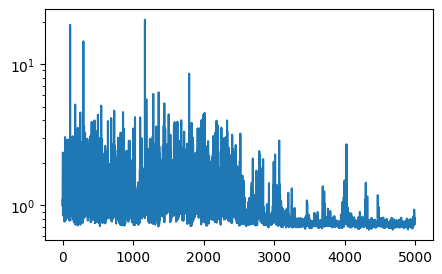

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log")